In [203]:
from astropy.io import fits
import numpy as np
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord, Galactocentric
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy.coordinates import Angle
hdul = fits.open('galah_dr4_allstar_240705.fits')

CHOOSING STARS 
Goal of this is to have a variety of stars to map. To do so, we will use effective temperature, metallicity and radial velocity to differentiate the stars. We will use GALAH to survey this and choose 15 source IDs. 

In [75]:
data = hdul[1].data

star_IDs = []

filter1 = data[(data['fe_h'] < -1)]
sample = np.random.choice(len(filter1), 3, replace=False)
stargroup1 = filter1[sample]["gaiadr3_source_id"]
print("Star IDs with low metallicity - ", stargroup1 )

filter2 = data[(data['fe_h'] < 0) & (data['fe_h'] > -1)]
sample2 = np.random.choice(len(filter2), 2, replace=False)
stargroup2 = filter2[sample2]["gaiadr3_source_id"]
print("Star IDs with medium metallicity  - ", stargroup2 )

filter3 = data[(data['fe_h'] > np.abs(0.1))]
sample3 = np.random.choice(len(filter3), 1, replace=False)
stargroup3 = filter3[sample3]["gaiadr3_source_id"]
print("Star IDs with metallicity > 0.1 - ", stargroup3 )

filter4 = data[(data['teff'] > 5000)]
sample4 = np.random.choice(len(filter4), 2, replace=False)
stargroup4 = filter4[sample4]["gaiadr3_source_id"]
print("Star IDs with effective temperature > 5000 - ", stargroup4 )


filter5 = data[(data['teff'] < 5000)]
sample5 = np.random.choice(len(filter5), 2, replace=False)
stargroup5 = filter5[sample5]["gaiadr3_source_id"]
print("Star IDs with effective temperature < 5000 - ", stargroup5 )

filter6 = data[(data['teff'] > 7000)]
sample6 = np.random.choice(len(filter6), 1, replace=False)
stargroup6 = filter6[sample6]["gaiadr3_source_id"]
print("Star IDs with effective temperature > 7500 - ", stargroup6 )

filter7 = data[(data['logg'] > 4)]
sample7 = np.random.choice(len(filter7), 2, replace=False)
stargroup7 = filter7[sample7]["gaiadr3_source_id"]
print("Star IDs with logg > 4 (dwarfs) - ", stargroup7 )


filter8 = data[(data['logg'] < 3)]
sample8 = np.random.choice(len(filter8), 2, replace=False)
stargroup8 = filter8[sample8]["gaiadr3_source_id"]
print("Star IDs with logg < 3 (giants) - ", stargroup8 )



star_IDs = np.concatenate([
    stargroup1,
    stargroup2,
    stargroup3,
    stargroup4,
    stargroup5,
    stargroup6,
    stargroup7,
    stargroup8
])
print(star_IDs)

Star IDs with low metallicity -  [6729258900007861760 3609569787770705536 6008324793721221248]
Star IDs with medium metallicity  -  [5808047887426360960 5833417542038685056]
Star IDs with metallicity > 0.1 -  [6585201058328327936]
Star IDs with effective temperature > 5000 -  [5819859361031187840 6119968414125327104]
Star IDs with effective temperature < 5000 -  [5307469281591173120 3896088396116548096]
Star IDs with effective temperature > 7500 -  [3118789303699610368]
Star IDs with logg > 4 (dwarfs) -  [3336102279369305472 6688856280086460800]
Star IDs with logg < 3 (giants) -  [5986399501100448000 6737344772932900736]
[6729258900007861760 3609569787770705536 6008324793721221248
 5808047887426360960 5833417542038685056 6585201058328327936
 5819859361031187840 6119968414125327104 5307469281591173120
 3896088396116548096 3118789303699610368 3336102279369305472
 6688856280086460800 5986399501100448000 6737344772932900736]


creating job for Gaia 

In [45]:
star_list = ",".join(str(i) for i in star_IDs)

query = f"""
SELECT source_id, ra, dec, pmra, pmdec, parallax, radial_velocity
FROM gaiadr3.gaia_source
WHERE source_id IN ({star_list})
"""

job = Gaia.launch_job(query)
gaia_results = job.get_results()

Coords for 

In [65]:
coords = SkyCoord(
    ra = gaia_results['ra'],
    dec = gaia_results['dec'], 
    distance = 1000/gaia_results['parallax'] * u.pc,
    pm_ra_cosdec = gaia_results['pmra'],
    pm_dec = gaia_results['pmdec'],
    radial_velocity = gaia_results['radial_velocity']
)

In [67]:
print(coords)

<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, pc)
    [(231.77214193, -65.50123366,  1358.85186308),
     (211.98737091, -65.7801848 ,   665.35647368),
     (140.4404545 ,  -1.94155166,  1852.34511644),
     ( 98.53376441, -12.54295369,  5906.29901172),
     (279.83058128, -35.92364333,   350.9316493 ),
     (176.22476909, -45.08349919,   663.33215029),
     (239.49493125, -25.88709009,  2310.74083741),
     (218.74970079, -60.05036896,  2382.10179515),
     (172.49001271, -56.07867257,   909.31794209),
     (124.05223017, -34.02564283,  3345.38789726),
     ( 72.03610216, -61.67750519,  3185.21680354),
     (271.52357228, -47.12811339, 11752.81325431),
     (301.41413191,  -5.87639931,  1286.20611771),
     (201.79679127, -37.91516946,  2869.75006824),
     (325.7719323 , -66.84665715,  2013.02323641)]
 (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
    [( -4.90515759,   2.32257181,   10.597366 ),
     ( -8.38660347, -17.46329892,  -50.188137 ),
     ( -

In [71]:
galactic_coords = coords.galactic
l = galactic_coords.l   
b = galactic_coords.b    
d = galactic_coords.distance 

print(l, b, d)

[318d09m27.77388995s 310d40m37.08380955s 234d11m13.71817011s
 222d14m59.95146045s 359d06m59.12345205s 290d46m49.3108997s
 347d13m52.3484985s 315d31m23.3795175s 291d41m16.77652465s
 252d19m37.55100802s 271d43m37.16302974s 346d01m02.26924411s
 36d09m42.24809549s 310d40m03.23257175s 325d24m09.94665804s] [-7d20m26.42245345s -4d03m55.99269696s 31d48m17.38684327s
 -9d28m16.56692561s -13d15m52.16802122s 16d12m45.1076218s
 20d31m47.88890938s 0d15m54.48252901s 5d00m14.65752287s 0d39m31.91172663s
 -38d09m07.69052723s -12d25m29.66129512s -19d10m17.86926664s
 24d25m08.45728395s -41d06m40.26880774s] [ 1358.85186308   665.35647368  1852.34511644  5906.29901172
   350.9316493    663.33215029  2310.74083741  2382.10179515
   909.31794209  3345.38789726  3185.21680354 11752.81325431
  1286.20611771  2869.75006824  2013.02323641] pc


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


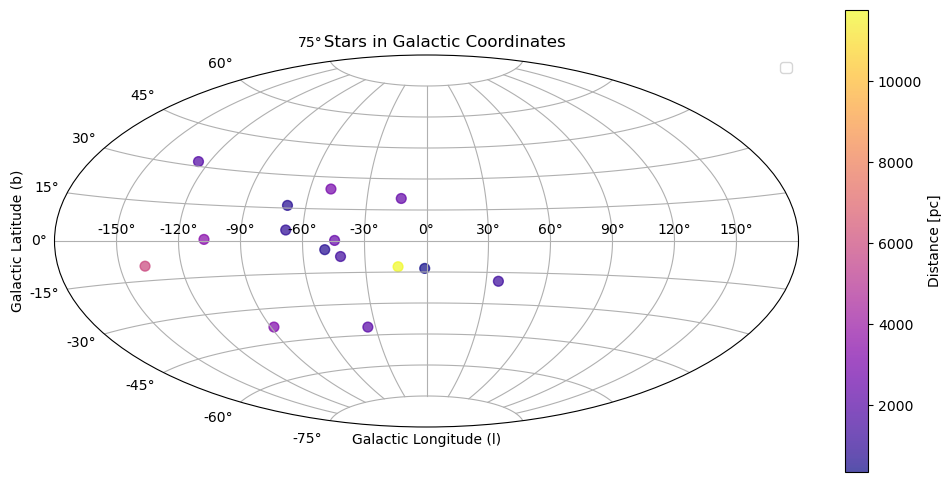

In [143]:
l_rad = galactic_coords.l.wrap_at(180*u.deg).radian  
b_rad = galactic_coords.b.radian

distances = galactic_coords.distance.value

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection="aitoff")
ax.grid(True)


sc = ax.scatter(l_rad, b_rad, c=distances, cmap='plasma', s=50, alpha=0.7)

cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.05)
cbar.set_label("Distance [pc]")

#for i, sid in enumerate(star_IDs):
   # ax.text(
        #l_rad[i], b_rad[i], str(sid), 
        #fontsize=6, ha='right', va='bottom', color='blue'
    #)

ax.set_title("       Stars in Galactic Coordinates")
ax.set_xlabel("Galactic Longitude (l)")
ax.set_ylabel("Galactic Latitude (b)")
ax.legend()
plt.savefig("AitoffColourBar.png")
plt.show()


nearer stars are bigger

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


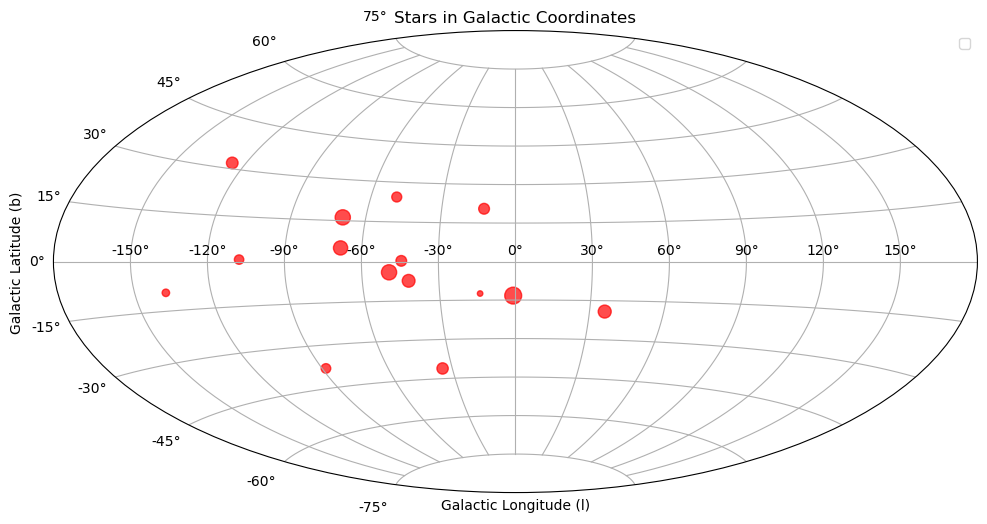

In [149]:
l_rad = galactic_coords.l.wrap_at(180*u.deg).radian  
b_rad = galactic_coords.b.radian

distances = galactic_coords.distance.value

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection="aitoff")
ax.grid(True)

size = 200 / (galactic_coords.distance.value/1000 + 1)

sc = ax.scatter(l_rad, b_rad, c='red', s=size, alpha=0.7)



#for i, sid in enumerate(star_IDs):
   # ax.text(
        #l_rad[i], b_rad[i], str(sid), 
        #fontsize=6, ha='right', va='bottom', color='blue'
    #)

ax.set_title("Stars in Galactic Coordinates")
ax.set_xlabel("Galactic Longitude (l)")
ax.set_ylabel("Galactic Latitude (b)")
ax.legend()
plt.savefig("AitoffSizeVariation.png")
plt.show()

In [161]:
x = galactic_coords.cartesian.x.value  
y = galactic_coords.cartesian.y.value  
z = galactic_coords.cartesian.z.value

print(x, y, z)

[ 1004.02573818   432.58377874  -921.1340266  -4312.35315741
   341.52861982   225.98243529  2110.46754689  1699.69176455
   334.75948936 -1015.53398808    75.48646288 11137.45425731
   980.83241702  1702.83805094  1248.47784234] [ -899.03683906  -503.33417006 -1276.57998277 -3917.06396581
    -5.26724129  -595.51767724  -478.27774488 -1668.9324014
  -841.72683976 -3187.29211751 -2503.63147997 -2773.30819687
   716.8553839  -1982.00032672  -861.17832003] [ -173.61873423   -47.17228737   976.23669416  -971.89924859
   -80.52006269   185.20306868   810.37050166    11.02304592
    79.3166522     38.46894703 -1967.67306532 -2528.73361631
  -422.38880847  1186.37377387 -1323.60776993]


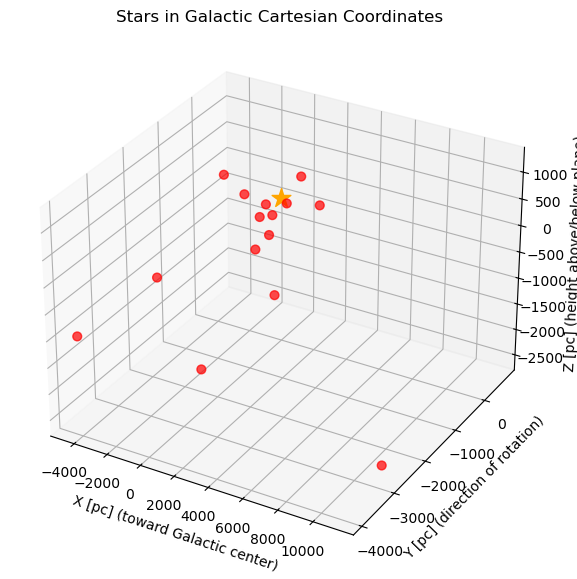

In [163]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(0, 0, 0, color='orange', s=200, marker='*', label='Sun')
sc = ax.scatter(x, y, z, c='red', s=40, alpha=0.7)



ax.set_xlabel('X [pc] (toward Galactic center)')
ax.set_ylabel('Y [pc] (direction of rotation)')
ax.set_zlabel('Z [pc] (height above/below plane)')
ax.set_title('Stars in Galactic Cartesian Coordinates')
plt.savefig("3D.png")
plt.show()

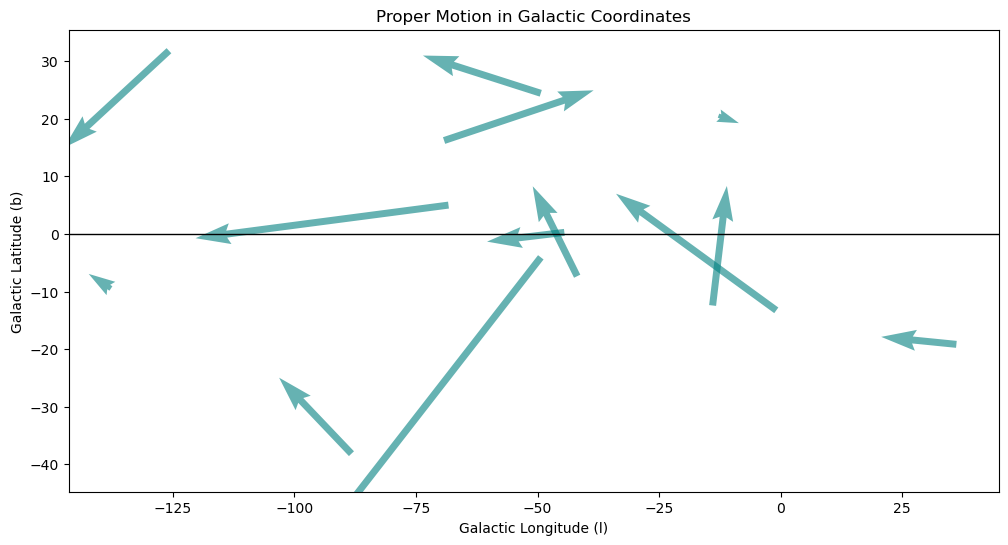

In [269]:
gal = coords.galactic

plt.figure(figsize=(12, 6))

plt.quiver(
    gal.l.wrap_at('180d').degree,
    gal.b.degree,
    gal.pm_l_cosb.value * 50, 
    gal.pm_b.value * 50,
    angles='xy',
    scale_units='xy',
    scale=15,
    color='teal',
    alpha=0.6
)

plt.axhline(0, color='black', lw=1)
plt.xlabel("Galactic Longitude (l)")
plt.ylabel("Galactic Latitude (b)")
plt.title("Proper Motion in Galactic Coordinates")
plt.savefig("Proper Motion")
plt.show()